# Replication of Low (2005) using HARK

**Paper:** Hamish W. Low, "Self-Insurance in a Life-Cycle Model of Labour
Supply and Savings," *Review of Economic Dynamics*, 8(4), 945-975, 2005.

This notebook replicates the key results: life-cycle profiles of consumption,
labor supply, and assets with and without uncertainty, and with flexible vs
fixed hours. These correspond to Figures 3-7 of the paper.

**Model scope:** Working life only (ages 25-64, 40 periods). The retirement
phase (ages 65-84) is noted as a future extension because HARK's
`LaborIntMargConsumerType` requires a positive wage rate each period.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.ConsumptionSaving.ConsLaborModel import LaborIntMargConsumerType
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

# === Low (2005) Published Calibration (Table 1, p.959) ===
gamma_low = 2.2          # CRRA over composite good
eta_low = 0.4            # consumption share in Cobb-Douglas utility
beta_low = 1.0 / 1.032   # discount factor (1 + delta = 1.032)
r_low = 0.016            # real interest rate

# Wage profile: log w(t) = alpha1*t + alpha2*t^2
alpha1_wage = 0.0561
alpha2_wage = -0.000599

# Shock variances (Low 2005, p.959)
sigma_nu_sq = 0.030      # permanent shock variance
sigma_eps_sq = 0.031     # transitory shock variance
sigma_perm = np.sqrt(sigma_nu_sq)   # ~0.173
sigma_tran = np.sqrt(sigma_eps_sq)  # ~0.176

# Life-cycle parameters
T_work = 40              # working years (age 25-64)
start_age = 25

# === HARK Parameter Mapping ===
# Low: u = (c^eta * z^(1-eta))^(1-gamma) / (1-gamma), z = leisure
# HARK: u = (c * z^alpha)^(1-rho) / (1-rho)
# => alpha = (1-eta)/eta, rho = 1 - eta*(1-gamma)
CRRA_hark = 1.0 - eta_low * (1.0 - gamma_low)
alpha_hark = (1.0 - eta_low) / eta_low
DiscFac = beta_low
Rfree = 1.0 + r_low

print(f"Low (2005): gamma={gamma_low}, eta={eta_low}")
print(f"HARK:       CRRA={CRRA_hark:.4f}, LbrCost alpha={alpha_hark:.4f}")
print(f"Discount factor: {DiscFac:.6f}")
print(f"Gross interest rate: {Rfree:.4f}")
print(f"Permanent shock std: {sigma_perm:.4f}  (variance {sigma_nu_sq})")
print(f"Transitory shock std: {sigma_tran:.4f}  (variance {sigma_eps_sq})")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Low (2005): gamma=2.2, eta=0.4
HARK:       CRRA=1.4800, LbrCost alpha=1.5000
Discount factor: 0.968992
Gross interest rate: 1.0160
Permanent shock std: 0.1732  (variance 0.03)
Transitory shock std: 0.1761  (variance 0.031)


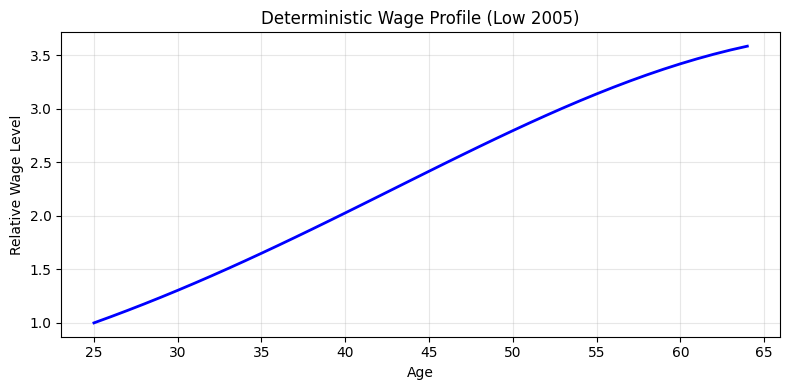

In [2]:
PermGroFac_list = [
    float(np.exp(alpha1_wage + alpha2_wage * (2 * t + 1)))
    for t in range(T_work)
]

ages = np.arange(start_age, start_age + T_work)
cum_log_wage = np.cumsum([0.0] + [np.log(g) for g in PermGroFac_list[:-1]])
wage_profile = np.exp(cum_log_wage)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages, wage_profile, "b-", linewidth=2)
ax.set_xlabel("Age")
ax.set_ylabel("Relative Wage Level")
ax.set_title("Deterministic Wage Profile (Low 2005)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model 1: Flexible hours with uncertainty

The main model from Low (2005). Agents choose consumption and labor
supply each period, facing permanent and transitory wage shocks.

In [3]:
base_dict = {
    "cycles": 1,
    "T_cycle": T_work,
    "CRRA": CRRA_hark,
    "DiscFac": DiscFac,
    "Rfree": [Rfree] * T_work,
    "LivPrb": [1.0] * T_work,
    "PermGroFac": PermGroFac_list,
    "WageRte": [1.0] * T_work,
    "PermShkCount": 7,
    "TranShkCount": 7,
    "UnempPrb": 0.0,
    "UnempPrbRet": 0.0,
    "T_retire": 0,
    "IncUnemp": 0.0,
    "IncUnempRet": 0.0,
    "BoroCnstArt": None,
    "LbrCostCoeffs": [float(np.log(alpha_hark))],
    "aXtraMin": 0.001,
    "aXtraMax": 50.0,
    "aXtraCount": 48,
    "aXtraNestFac": 3,
    "aXtraExtra": None,
    "vFuncBool": False,
    "CubicBool": False,
    "AgentCount": 10000,
    "T_age": T_work + 1,
    "T_sim": T_work,
    "aNrmInitMean": -10.0,
    "aNrmInitStd": 0.0,
    "pLvlInitMean": 0.0,
    "pLvlInitStd": 0.0,
    "PermGroFacAgg": 1.0,
    "NewbornTransShk": False,
    "PerfMITShk": False,
    "neutral_measure": False,
}

In [4]:
uncert_dict = base_dict.copy()
uncert_dict["PermShkStd"] = [sigma_perm] * T_work
uncert_dict["TranShkStd"] = [sigma_tran] * T_work

agent = LaborIntMargConsumerType(**uncert_dict)
agent.solve()
print(f"Flexible-hours + uncertainty model solved ({T_work} periods).")

agent.track_vars = ["cNrm", "Lbr", "aNrm", "pLvl"]
agent.initialize_sim()
agent.simulate()

flex_u_c = np.mean(agent.history["cNrm"] * agent.history["pLvl"], axis=1)
flex_u_L = np.mean(agent.history["Lbr"], axis=1)
flex_u_a = np.mean(agent.history["aNrm"] * agent.history["pLvl"], axis=1)

print(f"Mean labor (frac of time): {np.mean(flex_u_L):.4f}  (target: 0.40)")
print(f"Peak assets at age: {ages[np.argmax(flex_u_a)]}")

/Users/mac/github/econ-ark/ballpark/.venv-darwin-arm64/lib/python3.12/site-packages/HARK/rewards.py:79: RuntimeWarning: divide by zero encountered in power
  return c**-rho


Flexible-hours + uncertainty model solved (40 periods).
Mean labor (frac of time): 0.3586  (target: 0.40)
Peak assets at age: 56


## Model 2: Flexible hours, no uncertainty (certainty case)

Under certainty, agents have no precautionary motive. Comparing certainty
vs uncertainty isolates the self-insurance effects (Figures 3-5).

In [5]:
cert_dict = base_dict.copy()
cert_dict["PermShkStd"] = [0.001] * T_work
cert_dict["TranShkStd"] = [0.001] * T_work

cert_agent = LaborIntMargConsumerType(**cert_dict)
cert_agent.solve()

cert_agent.track_vars = ["cNrm", "Lbr", "aNrm", "pLvl"]
cert_agent.initialize_sim()
cert_agent.simulate()

flex_c_c = np.mean(cert_agent.history["cNrm"] * cert_agent.history["pLvl"], axis=1)
flex_c_L = np.mean(cert_agent.history["Lbr"], axis=1)
flex_c_a = np.mean(cert_agent.history["aNrm"] * cert_agent.history["pLvl"], axis=1)

print("Flexible-hours + certainty model solved.")

Flexible-hours + certainty model solved.


## Model 3: Fixed hours + uncertainty

Using HARK's `IndShockConsumerType` (exogenous labor). This comparison
shows how labor flexibility affects precautionary saving (Figure 6).

In [6]:
fixed_dict = {
    "cycles": 1,
    "T_cycle": T_work,
    "CRRA": gamma_low,
    "DiscFac": DiscFac,
    "Rfree": [Rfree] * T_work,
    "LivPrb": [1.0] * T_work,
    "PermGroFac": PermGroFac_list,
    "PermShkStd": [sigma_perm] * T_work,
    "TranShkStd": [sigma_tran] * T_work,
    "PermShkCount": 7,
    "TranShkCount": 7,
    "UnempPrb": 0.0,
    "UnempPrbRet": 0.0,
    "T_retire": 0,
    "IncUnemp": 0.0,
    "IncUnempRet": 0.0,
    "BoroCnstArt": 0.0,
    "aXtraMin": 0.001,
    "aXtraMax": 50.0,
    "aXtraCount": 48,
    "aXtraNestFac": 3,
    "AgentCount": 10000,
    "T_age": T_work + 1,
    "T_sim": T_work,
    "aNrmInitMean": -10.0,
    "aNrmInitStd": 0.0,
    "pLvlInitMean": 0.0,
    "pLvlInitStd": 0.0,
    "PermGroFacAgg": 1.0,
}

fixed_agent = IndShockConsumerType(**fixed_dict)
fixed_agent.solve()

fixed_agent.track_vars = ["cNrm", "aNrm", "pLvl"]
fixed_agent.initialize_sim()
fixed_agent.simulate()

fix_u_c = np.mean(fixed_agent.history["cNrm"] * fixed_agent.history["pLvl"], axis=1)
fix_u_a = np.mean(fixed_agent.history["aNrm"] * fixed_agent.history["pLvl"], axis=1)

print("Fixed-hours + uncertainty model solved.")

Fixed-hours + uncertainty model solved.


---
## Figure 1: Life-Cycle Profiles under Uncertainty, Flexible Hours
(cf. Low 2005, Figure 7)

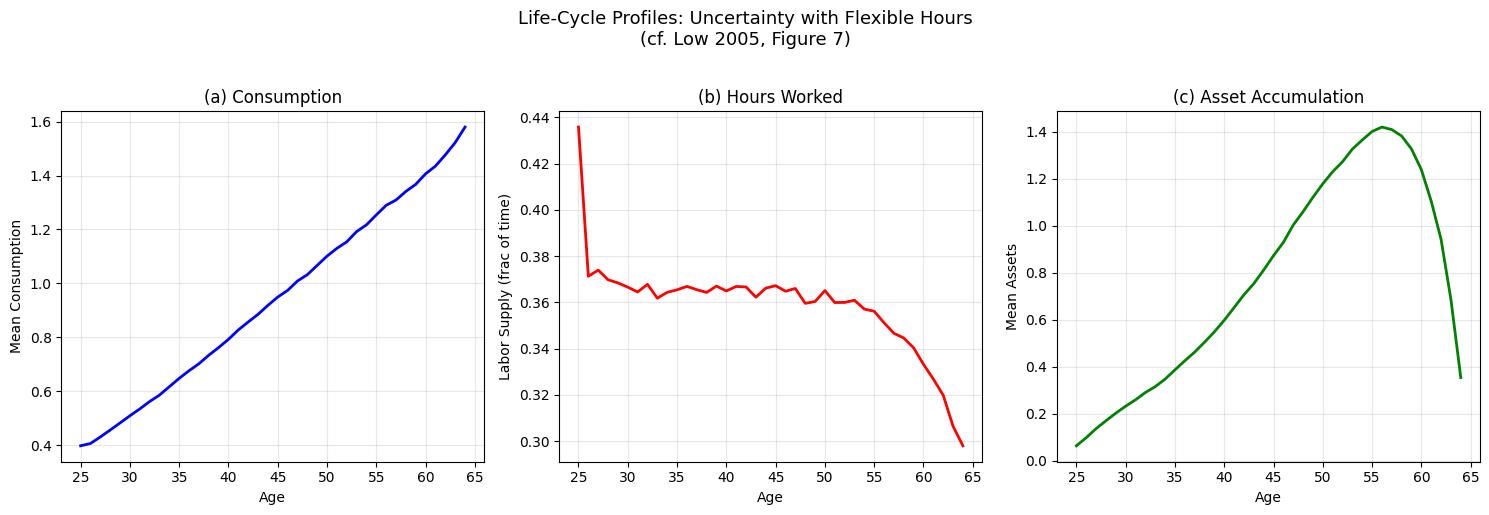

Saved: Figures/lifecycle_profiles.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(ages, flex_u_c, "b-", linewidth=2)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Mean Consumption")
axes[0].set_title("(a) Consumption")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ages, flex_u_L, "r-", linewidth=2)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Labor Supply (frac of time)")
axes[1].set_title("(b) Hours Worked")
axes[1].grid(True, alpha=0.3)

axes[2].plot(ages, flex_u_a, "g-", linewidth=2)
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Mean Assets")
axes[2].set_title("(c) Asset Accumulation")
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    "Life-Cycle Profiles: Uncertainty with Flexible Hours\n"
    "(cf. Low 2005, Figure 7)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("../../Figures/lifecycle_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Figures/lifecycle_profiles.png")

## Figure 2: Hours Worked — Certainty vs Uncertainty
(cf. Low 2005, Figure 3)

Under uncertainty, agents front-load work effort as a form of
precautionary behavior: they work more hours early in life.

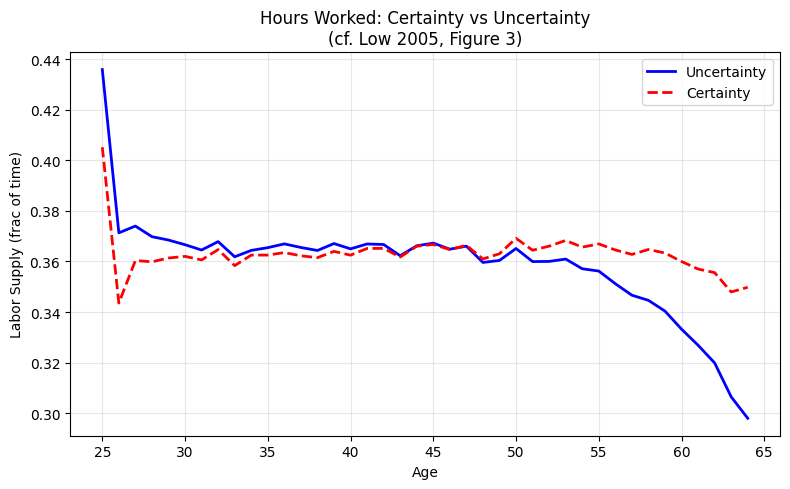

Saved: Figures/hours_cert_vs_uncert.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, flex_u_L, "b-", linewidth=2, label="Uncertainty")
ax.plot(ages, flex_c_L, "r--", linewidth=2, label="Certainty")
ax.set_xlabel("Age")
ax.set_ylabel("Labor Supply (frac of time)")
ax.set_title("Hours Worked: Certainty vs Uncertainty\n(cf. Low 2005, Figure 3)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../Figures/hours_cert_vs_uncert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Figures/hours_cert_vs_uncert.png")

## Figure 3: Consumption — Certainty vs Uncertainty
(cf. Low 2005, Figure 4)

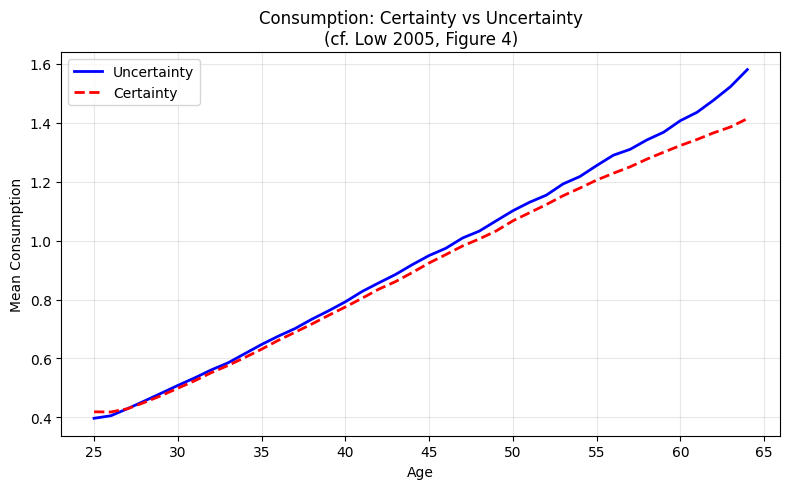

Saved: Figures/consumption_cert_vs_uncert.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, flex_u_c, "b-", linewidth=2, label="Uncertainty")
ax.plot(ages, flex_c_c, "r--", linewidth=2, label="Certainty")
ax.set_xlabel("Age")
ax.set_ylabel("Mean Consumption")
ax.set_title("Consumption: Certainty vs Uncertainty\n(cf. Low 2005, Figure 4)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../Figures/consumption_cert_vs_uncert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Figures/consumption_cert_vs_uncert.png")

## Figure 4: Assets — Certainty vs Uncertainty
(cf. Low 2005, Figure 5)

Precautionary saving under uncertainty leads to substantially higher
asset accumulation, especially in middle age.

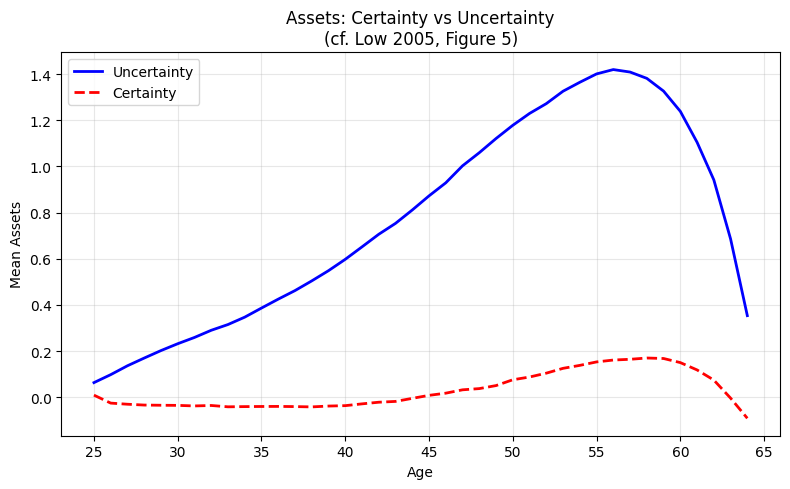

Saved: Figures/assets_cert_vs_uncert.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, flex_u_a, "b-", linewidth=2, label="Uncertainty")
ax.plot(ages, flex_c_a, "r--", linewidth=2, label="Certainty")
ax.set_xlabel("Age")
ax.set_ylabel("Mean Assets")
ax.set_title("Assets: Certainty vs Uncertainty\n(cf. Low 2005, Figure 5)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../Figures/assets_cert_vs_uncert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Figures/assets_cert_vs_uncert.png")

## Figure 5: Flexible vs Fixed Hours under Uncertainty
(cf. Low 2005, Figure 6)

When labor supply is flexible, agents use it as an additional
self-insurance mechanism, reducing the need for precautionary saving.

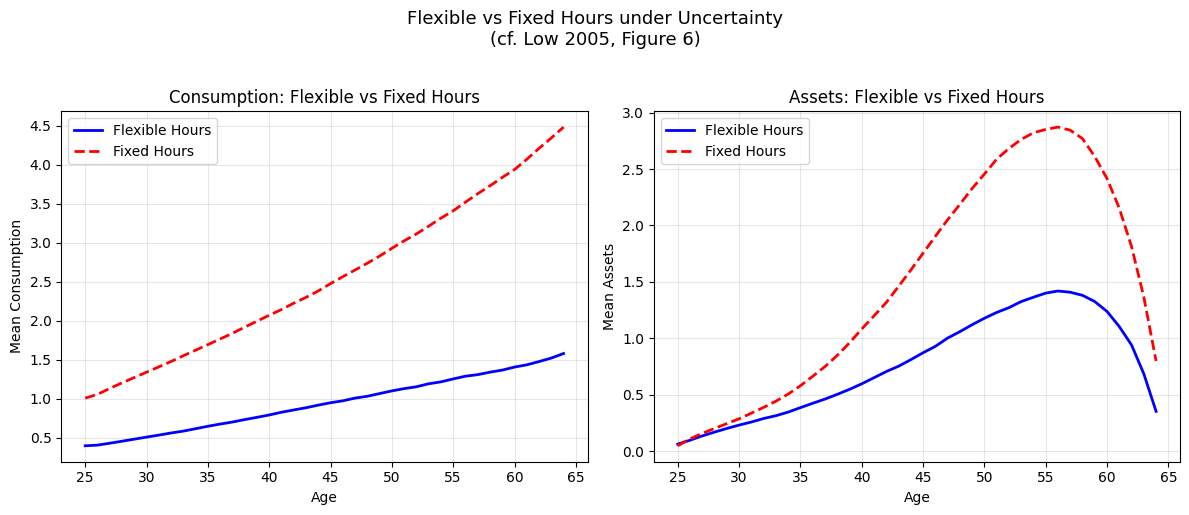

Saved: Figures/flexible_vs_fixed.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ages, flex_u_c, "b-", linewidth=2, label="Flexible Hours")
axes[0].plot(ages, fix_u_c, "r--", linewidth=2, label="Fixed Hours")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Mean Consumption")
axes[0].set_title("Consumption: Flexible vs Fixed Hours")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ages, flex_u_a, "b-", linewidth=2, label="Flexible Hours")
axes[1].plot(ages, fix_u_a, "r--", linewidth=2, label="Fixed Hours")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Mean Assets")
axes[1].set_title("Assets: Flexible vs Fixed Hours")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "Flexible vs Fixed Hours under Uncertainty\n(cf. Low 2005, Figure 6)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("../../Figures/flexible_vs_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Figures/flexible_vs_fixed.png")

## Summary Statistics

Comparison with Low (2005) Table 1 calibration targets:
- Mean hours share (working age): ~0.40
- Median assets/income ratio (working age): 1.84
- Aggregate assets/income ratio (working age): 2.14

In [12]:
print("\n" + "=" * 60)
print("Summary: Replication vs Low (2005) Targets")
print("=" * 60)
print(f"{'Statistic':<40} {'Model':>10} {'Target':>10}")
print("-" * 60)
print(f"{'Mean hours (working, frac of time)':<40} {np.mean(flex_u_L):.4f}     {'0.40':>5}")
print(f"{'Peak assets age':<40} {ages[np.argmax(flex_u_a)]:>5d}     {'~60':>5}")
print(f"{'Mean consumption (working)':<40} {np.mean(flex_u_c):.4f}     {'--':>5}")
print("=" * 60)
print("\nKey qualitative results:")
print(f"  Uncertainty raises hours early in life: "
      f"{flex_u_L[0]:.3f} (uncert) vs {flex_c_L[0]:.3f} (cert)")
print(f"  Uncertainty raises asset accumulation: "
      f"{np.max(flex_u_a):.2f} (uncert) vs {np.max(flex_c_a):.2f} (cert)")
print(f"  Flexible hours reduce precautionary saving: "
      f"{np.max(flex_u_a):.2f} (flex) vs {np.max(fix_u_a):.2f} (fixed)")


Summary: Replication vs Low (2005) Targets
Statistic                                     Model     Target
------------------------------------------------------------
Mean hours (working, frac of time)       0.3586      0.40
Peak assets age                             56       ~60
Mean consumption (working)               0.9395        --

Key qualitative results:
  Uncertainty raises hours early in life: 0.436 (uncert) vs 0.405 (cert)
  Uncertainty raises asset accumulation: 1.42 (uncert) vs 0.17 (cert)
  Flexible hours reduce precautionary saving: 1.42 (flex) vs 2.87 (fixed)
